In [13]:
import pandas as pd
import numpy as np
import pickle

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load datasets
X_train_selected = pd.read_parquet("X_train_selected.parquet")
X_test_selected = pd.read_parquet("X_test_selected.parquet")

y_train = pd.read_parquet("y_train.parquet")["label"]
y_test = pd.read_parquet("y_test.parquet")["label"]

# Load artifacts
with open("labelencoder.pkl", "rb") as f:
    le = pickle.load(f)

print("Data loaded successfully")
print("Train shape:", X_train_selected.shape)
print("Test shape:", X_test_selected.shape)


Data loaded successfully
Train shape: (467596, 48)
Test shape: (116899, 48)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(
    solver="saga",
    multi_class="multinomial",
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_selected, y_train)

y_pred_lr = lr.predict(X_test_selected)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.92      0.38      0.54     49601
           1       0.12      0.03      0.05      2124
           2       0.76      0.81      0.79     64352
           3       0.00      0.00      0.00       287
           4       0.00      1.00      0.00         9
           5       0.06      0.39      0.11       391
           6       0.01      0.91      0.02       135

    accuracy                           0.61    116899
   macro avg       0.27      0.50      0.22    116899
weighted avg       0.81      0.61      0.66    116899



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_selected, y_train)

y_pred_rf = rf.predict(X_test_selected)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     49601
           1       0.99      0.92      0.95      2124
           2       1.00      1.00      1.00     64352
           3       0.53      0.99      0.69       287
           4       1.00      0.67      0.80         9
           5       0.95      0.99      0.97       391
           6       0.40      0.87      0.55       135

    accuracy                           0.99    116899
   macro avg       0.84      0.92      0.85    116899
weighted avg       1.00      0.99      0.99    116899



In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(y_train.unique()),
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train_selected, y_train)

y_pred_xgb = xgb.predict(X_test_selected)

print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))


XGBoost Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49601
           1       0.96      0.97      0.97      2124
           2       1.00      1.00      1.00     64352
           3       0.92      0.92      0.92       287
           4       1.00      0.78      0.88         9
           5       0.97      0.98      0.97       391
           6       0.47      0.34      0.39       135

    accuracy                           1.00    116899
   macro avg       0.90      0.86      0.88    116899
weighted avg       1.00      1.00      1.00    116899



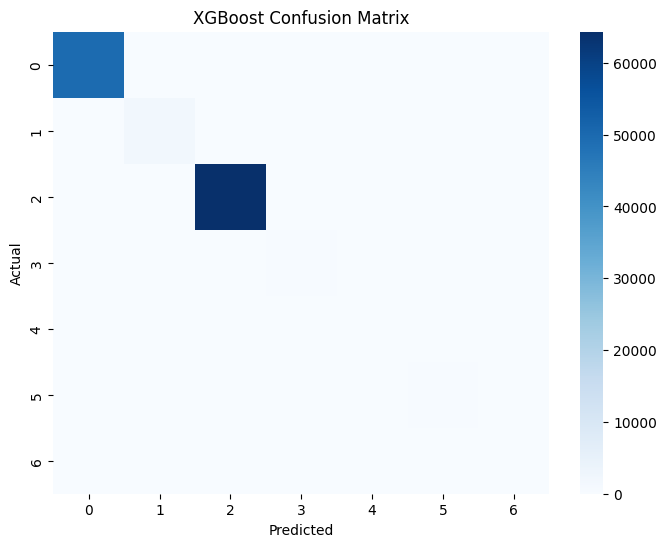

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, y_pred_xgb, "XGBoost Confusion Matrix")


In [20]:
from sklearn.metrics import f1_score, classification_report

# Collect predictions
predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

# Evaluate F1-score (macro-average for multi-class)
f1_scores = {}
for name, y_pred in predictions.items():
    f1 = f1_score(y_test, y_pred, average="macro")
    f1_scores[name] = f1
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

# Select best model
best_model_name = max(f1_scores, key=f1_scores.get)
print(f"\n Best model based on F1-score: {best_model_name}")

# Map model name to trained object
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}
best_model = models[best_model_name]

# Save the final model
import pickle
with open("final_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"Final model saved: {best_model_name}")



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.38      0.54     49601
           1       0.12      0.03      0.05      2124
           2       0.76      0.81      0.79     64352
           3       0.00      0.00      0.00       287
           4       0.00      1.00      0.00         9
           5       0.06      0.39      0.11       391
           6       0.01      0.91      0.02       135

    accuracy                           0.61    116899
   macro avg       0.27      0.50      0.22    116899
weighted avg       0.81      0.61      0.66    116899

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     49601
           1       0.99      0.92      0.95      2124
           2       1.00      1.00      1.00     64352
           3       0.53      0.99      0.69       287
           4       1.00      0.67      0.80         9
           5       0.95     